In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

Mounted at /content/drive


In [2]:
df_sift = pd.read_csv("/content/drive/MyDrive/sift_consecutive_pairs.csv")
df_orb = pd.read_csv("/content/drive/MyDrive/orb_consecutive_pairs.csv")
df_sp = pd.read_csv("/content/drive/MyDrive/superpoint_superglue_consecutive_pairs.csv")
df_disk = pd.read_csv("/content/drive/MyDrive/disk_lightglue_consecutive_pairs.csv")

print("SIFT:", len(df_sift), "rows")
print("ORB:", len(df_orb), "rows")
print("SuperPoint+SuperGlue:", len(df_sp), "rows")
print("DISK+LightGlue:", len(df_disk), "rows")

SIFT: 612 rows
ORB: 612 rows
SuperPoint+SuperGlue: 612 rows
DISK+LightGlue: 612 rows


In [3]:
summary = pd.DataFrame({
    "Algorithm": ["SIFT", "ORB", "SuperPoint+SuperGlue", "DISK+LightGlue"],
    "Matcher": ["FLANN", "BFMatcher(Hamming)", "SuperGlue", "LightGlue"],
    "Avg Matches": [df_sift["Matches"].mean(), df_orb["Matches"].mean(), df_sp["Matches"].mean(), df_disk["Matches"].mean()],
    "Avg Inliers": [df_sift["Inliers"].mean(), df_orb["Inliers"].mean(), df_sp["Inliers"].mean(), df_disk["Inliers"].mean()],
    "Avg Inlier Ratio": [df_sift["Inlier_Ratio"].mean(), df_orb["Inlier_Ratio"].mean(), df_sp["Inlier_Ratio"].mean(), df_disk["Inlier_Ratio"].mean()],
})

print(summary)
summary.to_csv("/content/drive/MyDrive/final_comparison_table.csv", index=False)
print("\nSaved final comparison table to Drive")

              Algorithm             Matcher  Avg Matches  Avg Inliers  \
0                  SIFT               FLANN   482.986928   453.204248   
1                   ORB  BFMatcher(Hamming)   793.535948   779.202614   
2  SuperPoint+SuperGlue           SuperGlue   495.807190   459.772876   
3        DISK+LightGlue           LightGlue  1482.673203  1456.155229   

   Avg Inlier Ratio  
0          0.926589  
1          0.978127  
2          0.921314  
3          0.980535  

Saved final comparison table to Drive


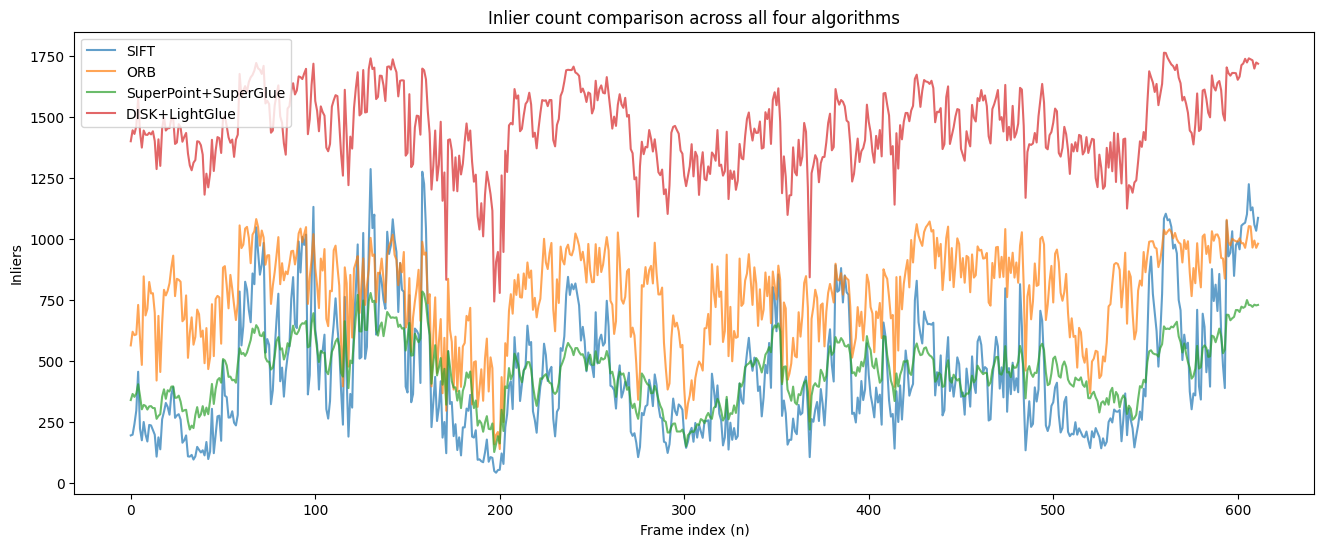

In [4]:
plt.figure(figsize=(16, 6))
plt.plot(df_sift["Frame_n"], df_sift["Inliers"], label="SIFT", alpha=0.7)
plt.plot(df_orb["Frame_n"], df_orb["Inliers"], label="ORB", alpha=0.7)
plt.plot(df_sp["Frame_n"], df_sp["Inliers"], label="SuperPoint+SuperGlue", alpha=0.7)
plt.plot(df_disk["Frame_n"], df_disk["Inliers"], label="DISK+LightGlue", alpha=0.7)
plt.xlabel("Frame index (n)")
plt.ylabel("Inliers")
plt.title("Inlier count comparison across all four algorithms")
plt.legend()
plt.savefig("/content/comparison_plot.png", dpi=100, bbox_inches='tight')
plt.close()

Image("/content/comparison_plot.png")

In [6]:
sift = cv2.SIFT_create()
orb = cv2.ORB_create(nfeatures=2000)

sift_counts = []
orb_counts = []

for f in image_files:
    img = cv2.imread(f)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp_s, _ = sift.detectAndCompute(gray, None)
    kp_o, _ = orb.detectAndCompute(gray, None)
    sift_counts.append(len(kp_s))
    orb_counts.append(len(kp_o))

print("Avg SIFT keypoints:", sum(sift_counts)/len(sift_counts))
print("Avg ORB keypoints:", sum(orb_counts)/len(orb_counts))

NameError: name 'cv2' is not defined